# Using a Pre-trained ViT for Image Classification 

In [1]:
from utils.sample_images import visualize, get_subset
from utils.get_label import get_label
from models.TIMM_vit_small_patch16_224 import build_vit_TIMM
from config import DEVICE
import torch

/home/ATML/atml-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


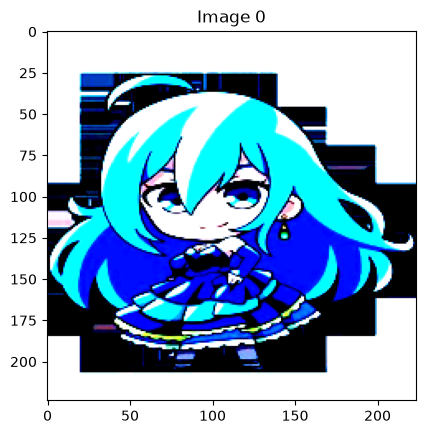

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.1632845].


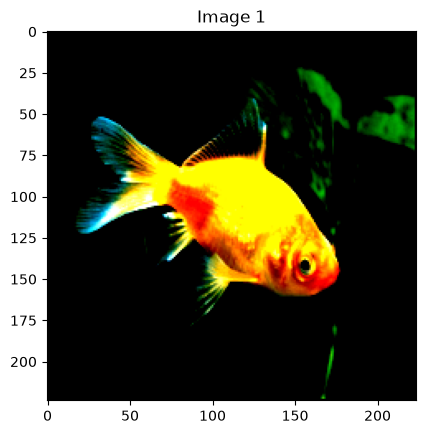

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.535425].


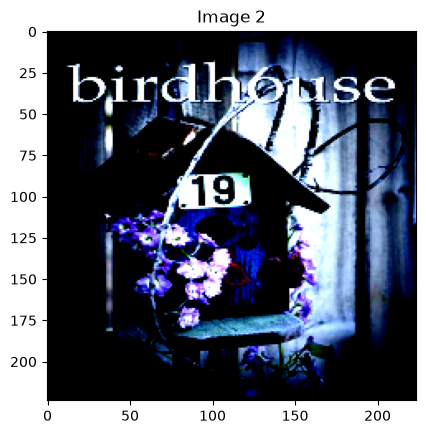

In [ ]:
model = build_vit_TIMM()
model.to(DEVICE)
model.eval()
dataset = get_subset()
visualize()

images = torch.stack([img for img, label in dataset]).to(DEVICE)


with torch.no_grad():
    output = model(images) 

top1_indices = output.argmax(dim=1) 

In [ ]:
get_label(idx)

Image 0: printer
Image 1: goldfish
Image 2: birdhouse


# Visualizing Patch Attention

In [2]:
from models.HF_vit_large_patch16_224 import build_vit_HF
from utils.vizualizing_attention import visualize_attention
from utils.overlay_attention import overlay_attention
from utils.rollout_attention import compute_attention_rollout
from utils.rollout_attention import overlay_rollout

In [4]:
image = 'data/images/images.jpg'

model_hf, processor_hf = build_vit_HF()
model_hf.to(DEVICE)
model_hf.eval()

input = processor_hf(images=image, return_tensors="pt")
input.to(DEVICE)
output = model_hf(**input, output_attentions=True)
attention_matrix = output.attentions[-1]

Loading weights: 100%|██████████| 392/392 [00:00<00:00, 21009.84it/s]


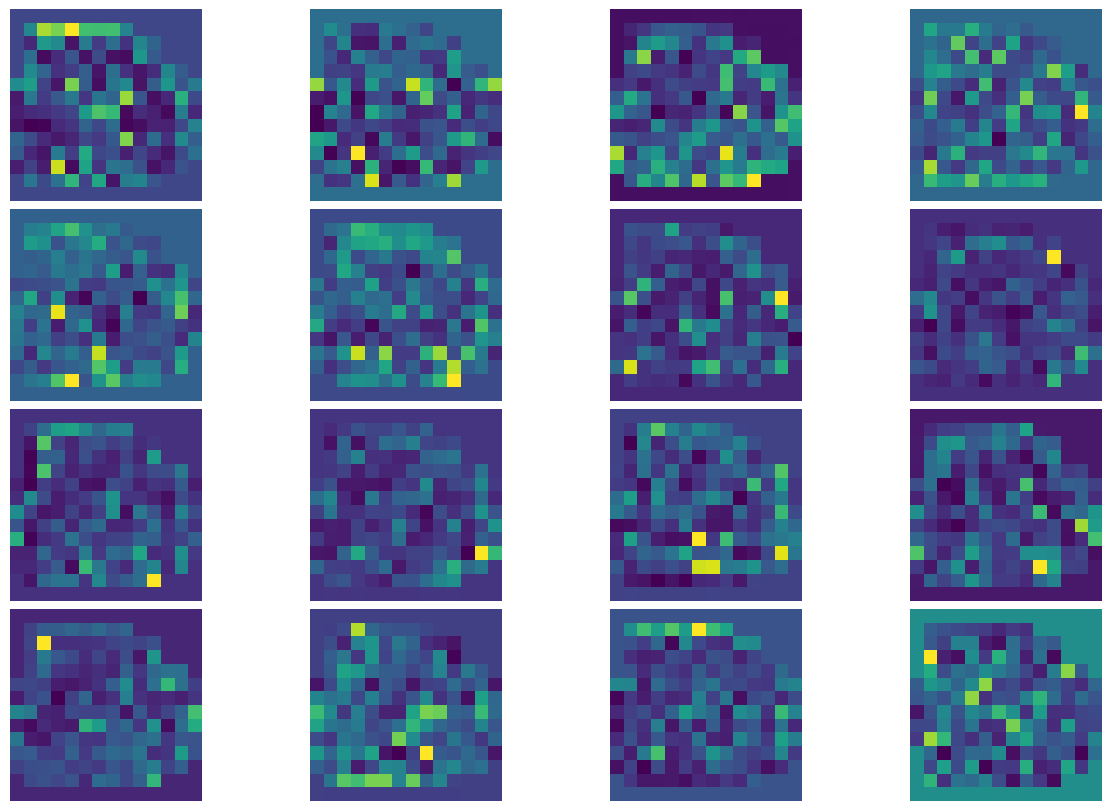

In [5]:
visualize_attention(attention_matrix)

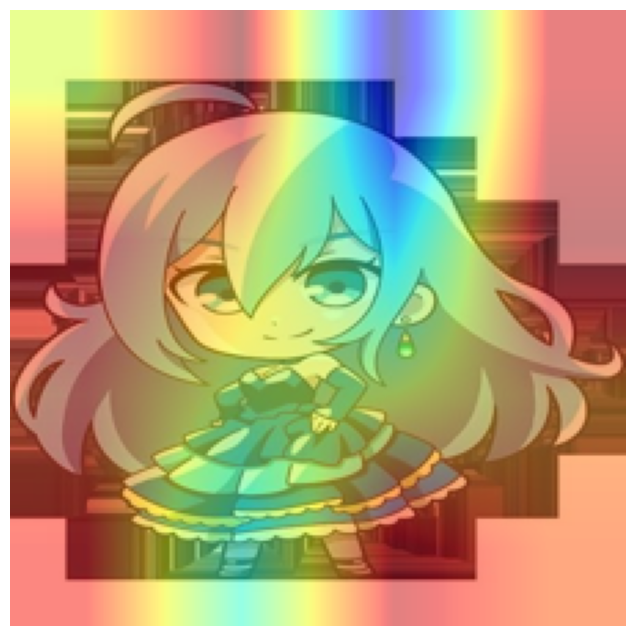

In [6]:
overlay_attention(attention_matrix, image)

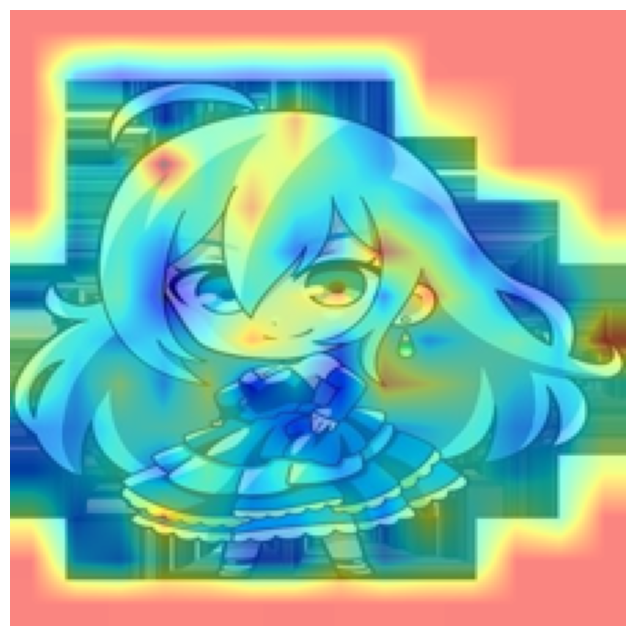

In [8]:
overlay_rollout(attention_matrix, image)

# Patch Masking Experiment

In [3]:
from utils.rand_masked_attention import mask_patches_rand, mask_patches_center, mask_patches_edges
from datasets import load_dataset

In [4]:
model_hf, processor_hf = build_vit_HF()
model_hf.to(DEVICE)
model_hf.eval()

Loading weights: 100%|██████████| 392/392 [00:00<00:00, 20035.18it/s]


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-23): 24 x ViTLayer(
        (attention): ViTAttention(
          (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
          (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
          (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
          (o_proj): Linear(in_features=1024, out_features=1024, bias=True)
        )
        (layernorm_before): LayerNorm((1024,), eps=1e-12, elementwise_affine=True, bias=True)
        (layernorm_after): LayerNorm((1024,), eps=1e-12, elementwise_affine=True, bias=True)
        (mlp): ViTMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (

In [5]:
dataset = load_dataset("ILSVRC/imagenet-1k", split="validation", streaming=True)
dataset_cached = list(dataset.take(500))  

In [6]:
sample = dataset_cached[0]
inp = processor_hf(images=sample["image"], return_tensors="pt").to(DEVICE)
with torch.no_grad():
    out = model_hf(**inp)
pred = out.logits.argmax(dim=-1).item()
print(f"True: {sample['label']} | Pred: {pred}")

True: 91 | Pred: 91



=== Strategy: random ===


  Ratio 0.00 → Accuracy: 0.802
  Ratio 0.10 → Accuracy: 0.686
  Ratio 0.25 → Accuracy: 0.436
  Ratio 0.50 → Accuracy: 0.096
  Ratio 0.75 → Accuracy: 0.012
  Ratio 0.90 → Accuracy: 0.006

=== Strategy: center ===
  Ratio 0.00 → Accuracy: 0.802
  Ratio 0.10 → Accuracy: 0.720
  Ratio 0.25 → Accuracy: 0.522
  Ratio 0.50 → Accuracy: 0.266
  Ratio 0.75 → Accuracy: 0.088
  Ratio 0.90 → Accuracy: 0.008

=== Strategy: edges ===
  Ratio 0.00 → Accuracy: 0.802
  Ratio 0.10 → Accuracy: 0.796
  Ratio 0.25 → Accuracy: 0.796
  Ratio 0.50 → Accuracy: 0.738
  Ratio 0.75 → Accuracy: 0.560
  Ratio 0.90 → Accuracy: 0.140


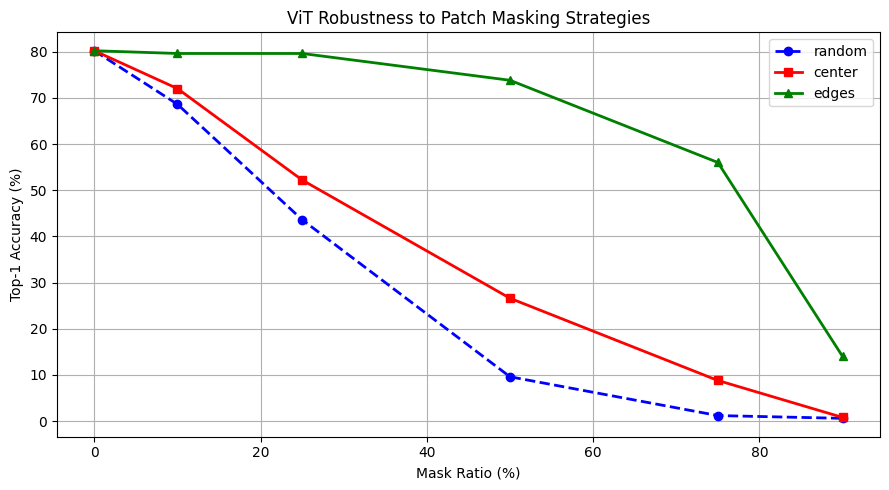


Final Results:

random:
  0.00 → 0.802
  0.10 → 0.686
  0.25 → 0.436
  0.50 → 0.096
  0.75 → 0.012
  0.90 → 0.006

center:
  0.00 → 0.802
  0.10 → 0.720
  0.25 → 0.522
  0.50 → 0.266
  0.75 → 0.088
  0.90 → 0.008

edges:
  0.00 → 0.802
  0.10 → 0.796
  0.25 → 0.796
  0.50 → 0.738
  0.75 → 0.560
  0.90 → 0.140


In [7]:
BATCH_SIZE = 512
mask_ratios = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9]

strategies = {
    "random": mask_patches_rand,
    "center": mask_patches_center,
    "edges":  mask_patches_edges,
}

results = {name: {} for name in strategies}

for strategy_name, mask_fn in strategies.items():
    print(f"\n=== Strategy: {strategy_name} ===")
    for ratio in mask_ratios:
        correct, total = 0, 0

        for i in range(0, len(dataset_cached), BATCH_SIZE):
            batch = dataset_cached[i:i+BATCH_SIZE]
            images = [s["image"] for s in batch]
            labels = [s["label"] for s in batch]

            masked_imgs = [mask_fn(img, ratio) for img in images]
            inp = processor_hf(images=masked_imgs, return_tensors="pt").to(DEVICE)

            with torch.no_grad():
                out = model_hf(**inp)

            preds = out.logits.argmax(dim=-1).tolist()
            correct += sum(p == l for p, l in zip(preds, labels))
            total += len(labels)

        acc = correct / total
        results[strategy_name][ratio] = acc
        print(f"  Ratio {ratio:.2f} → Accuracy: {acc:.3f}")

# --- plot ---
import matplotlib.pyplot as plt

styles = {
    "random": ("blue",  "o--"),
    "center": ("red",   "s-"),
    "edges":  ("green", "^-"),
}

plt.figure(figsize=(9, 5))
for strategy_name, res in results.items():
    color, linestyle = styles[strategy_name]
    ratios = [r * 100 for r in res.keys()]
    accs   = [v * 100 for v in res.values()]
    plt.plot(ratios, accs, linestyle, color=color, linewidth=2, label=strategy_name)

plt.xlabel("Mask Ratio (%)")
plt.ylabel("Top-1 Accuracy (%)")
plt.title("ViT Robustness to Patch Masking Strategies")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("patch_masking_robustness.png", dpi=150)
plt.show()

print("\nFinal Results:")
for strategy_name, res in results.items():
    print(f"\n{strategy_name}:")
    for ratio, acc in res.items():
        print(f"  {ratio:.2f} → {acc:.3f}")